In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Step 1: Load the dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')



In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  800 non-null    int64  
 1   Pclass       800 non-null    int64  
 2   Name         800 non-null    object 
 3   Sex          800 non-null    object 
 4   Age          800 non-null    int64  
 5   SibSp        800 non-null    int64  
 6   Parch        800 non-null    int64  
 7   Fare         800 non-null    float64
 8   Survived     800 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 56.4+ KB


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  200 non-null    int64  
 1   Pclass       200 non-null    int64  
 2   Name         200 non-null    object 
 3   Sex          200 non-null    object 
 4   Age          200 non-null    int64  
 5   SibSp        200 non-null    int64  
 6   Parch        200 non-null    int64  
 7   Fare         200 non-null    float64
dtypes: float64(1), int64(5), object(2)
memory usage: 12.6+ KB


In [5]:
train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,2.286250,37.977500,1.476250,0.972500,51.948162,0.38000
std,231.0844,0.807853,22.765485,1.129615,0.821637,27.302592,0.48569
min,1.0000,1.000000,1.000000,0.000000,0.000000,5.060000,0.00000
25%,200.7500,2.000000,19.000000,0.000000,0.000000,27.547500,0.00000
50%,400.5000,3.000000,36.000000,2.000000,1.000000,51.375000,0.00000
75%,600.2500,3.000000,58.000000,2.000000,2.000000,76.290000,1.00000
max,800.0000,3.000000,79.000000,3.000000,2.000000,99.960000,1.00000


In [11]:
train.shape

(800, 9)

In [13]:
test.shape

(200, 8)

In [15]:
# Check for missing values
print("Missing Values in Train:\n", train.isnull().sum())
print("\nMissing Values in Test:\n", test.isnull().sum())

Missing Values in Train:
 PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Survived       0
dtype: int64

Missing Values in Test:
 PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64


In [17]:
# Fill missing Age and Fare with median (if any)
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)
train['Fare'].fillna(train['Fare'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

In [19]:
# Outlier Detection and Removal (for 'Fare' and 'Age')
# Using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

train = remove_outliers(train, 'Fare')
train = remove_outliers(train, 'Age')


In [21]:
# Skewness Handling (for 'Fare' and 'Age')
# Log transformation for skewed features

train['Fare'] = np.log1p(train['Fare'])
test['Fare'] = np.log1p(test['Fare'])

# Check skewness
print("\nSkewness in Train Data:")
print("Fare:", skew(train['Fare']))
print("Age:", skew(train['Age']))


Skewness in Train Data:
Fare: -0.9163279012153349
Age: 0.10724346811849568


In [23]:
# Step: Encoding Categorical Variables
# Convert 'Sex' to numerical
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

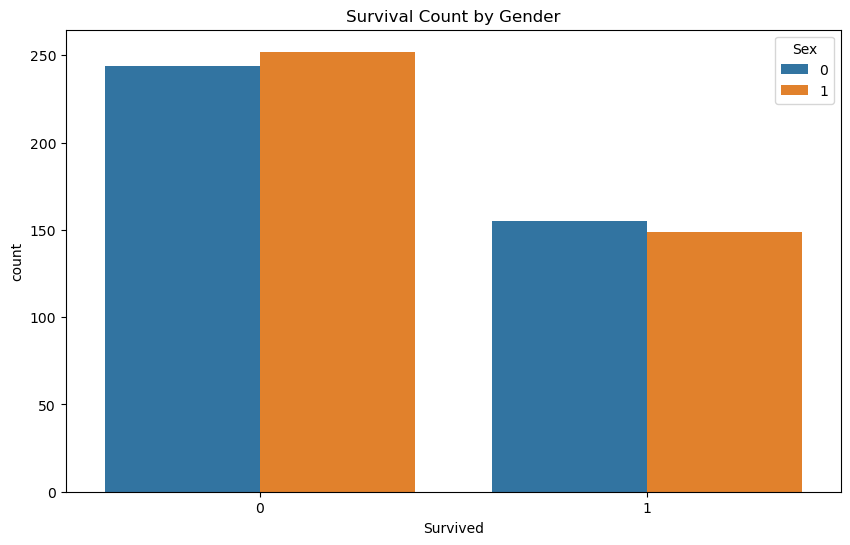

In [25]:
# Step : Data Exploration and Visualization
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='Survived', hue='Sex')
plt.title('Survival Count by Gender')
plt.show()



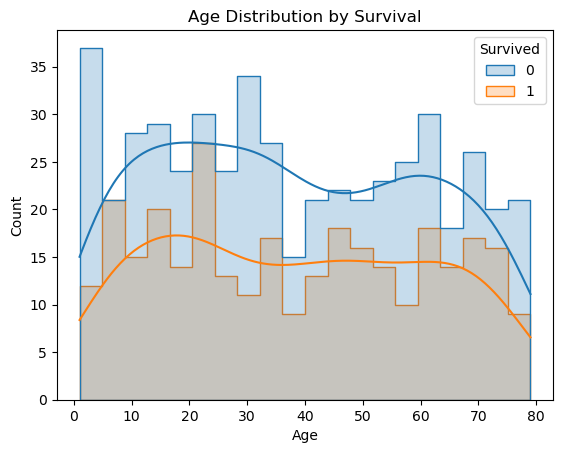

In [27]:
sns.histplot(data=train, x='Age', bins=20, hue='Survived', kde=True, element='step')
plt.title('Age Distribution by Survival')
plt.show()



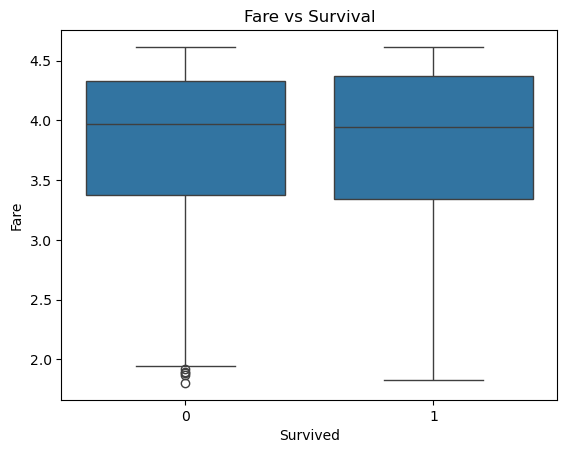

<Axes: xlabel='Pclass', ylabel='count'>

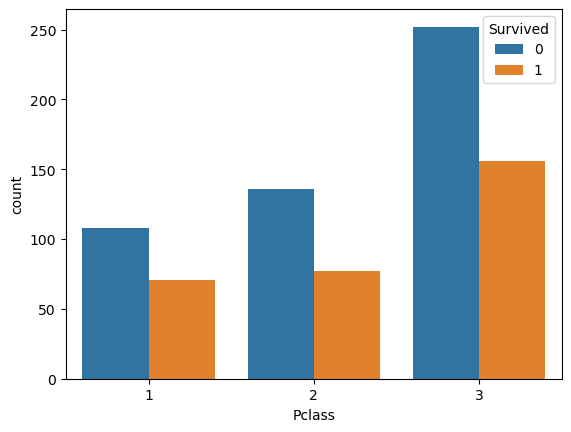

In [29]:
sns.boxplot(data=train, x='Survived', y='Fare')
plt.title('Fare vs Survival')
plt.show()

sns.countplot(data=train, x='Pclass', hue='Survived')


In [31]:
from sklearn.feature_selection import SelectKBest, f_classif

# Step 6: Feature Selection using SelectKBest
X = train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = train['Survived']
# Apply SelectKBest to choose the top features
selector = SelectKBest(score_func=f_classif, k=4)  # Select top 4 features
X_selected = selector.fit_transform(X, y)
# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected Features:", list(selected_features))

# Apply the same feature selection to the test set
X_test1 = test[selected_features]

Selected Features: ['Sex', 'Age', 'SibSp', 'Parch']


In [37]:

# Split the training set for validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [39]:
# Step 4: Model Building
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [41]:
# Step 5: Model Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.53125

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.79      0.66        92
           1       0.39      0.18      0.24        68

    accuracy                           0.53       160
   macro avg       0.48      0.48      0.45       160
weighted avg       0.49      0.53      0.48       160



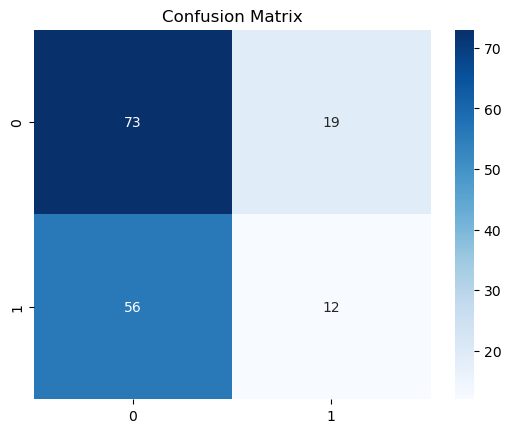

In [43]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()



In [45]:
# Step 6: Predict on Test Data and Save Submission
y_test_pred = model.predict(X_test1)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_test_pred
})

submission.to_csv('submission.csv', index=False)
print("Submission saved as 'submission.csv'")


Submission saved as 'submission.csv'
